# Trabajo Práctico 2 — Aprendizaje Profundo
### Carrera de Especialización en Inteligencia Artificial (CEIA)
### Facultad de Ingeniería — Universidad de Buenos Aires (FIUBA)

---

**Alumnos:**
- Di Grazia, María Gabriela — a2517
- García Miranda, Byron Isaac — a2524

**Cohorte:** 25Co2026
**Fecha de entrega:** 7 de agosto de 2026

---

In [10]:
# Primeramente vamos a ir agregando las librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Ahora bien en esta celda de codigo vamos a leer el archivo csv.

train = pd.read_csv('adult_train.csv')
val   = pd.read_csv('adult_val.csv')

print("Train:", train.shape)
print("Val:  ", val.shape)
print()
print(train.head())


Train: (30162, 14)
Val:   (15060, 14)

   age         workclass  education      marital-status         occupation  \
0   39         State-gov  Bachelors       Never-married       Adm-clerical   
1   50  Self-emp-not-inc  Bachelors  Married-civ-spouse    Exec-managerial   
2   38           Private    HS-grad            Divorced  Handlers-cleaners   
3   53           Private       11th  Married-civ-spouse  Handlers-cleaners   
4   28           Private  Bachelors  Married-civ-spouse     Prof-specialty   

    relationship   race     sex  capital-gain  capital-loss  hours-per-week  \
0  Not-in-family  White    Male          2174             0              40   
1        Husband  White    Male             0             0              13   
2  Not-in-family  White    Male             0             0              40   
3        Husband  Black    Male             0             0              40   
4           Wife  Black  Female             0             0              40   

               sk

In [2]:
# Análisis de cardinalidad de variables categoricas
categoricas = ['workclass','education','marital-status','occupation',
               'relationship','race','sex','skill-profile','native-country']

print("CARDINALIDAD (10+ valores únicos = ALTA cardinalidad)")
print("="*55)
for col in categoricas:
    n = train[col].nunique()
    nivel = "ALTA" if n >= 10 else "baja"
    print(f"  {col:20s} {n:>3d} valores  ->  {nivel}")

print()
print("Distribución del target (income):")
print(train['income'].value_counts())

CARDINALIDAD (10+ valores únicos = ALTA cardinalidad)
  workclass              7 valores  ->  baja
  education             16 valores  ->  ALTA
  marital-status         7 valores  ->  baja
  occupation            14 valores  ->  ALTA
  relationship           6 valores  ->  baja
  race                   5 valores  ->  baja
  sex                    2 valores  ->  baja
  skill-profile         80 valores  ->  ALTA
  native-country        41 valores  ->  ALTA

Distribución del target (income):
income
<=50K    22654
>50K      7508
Name: count, dtype: int64


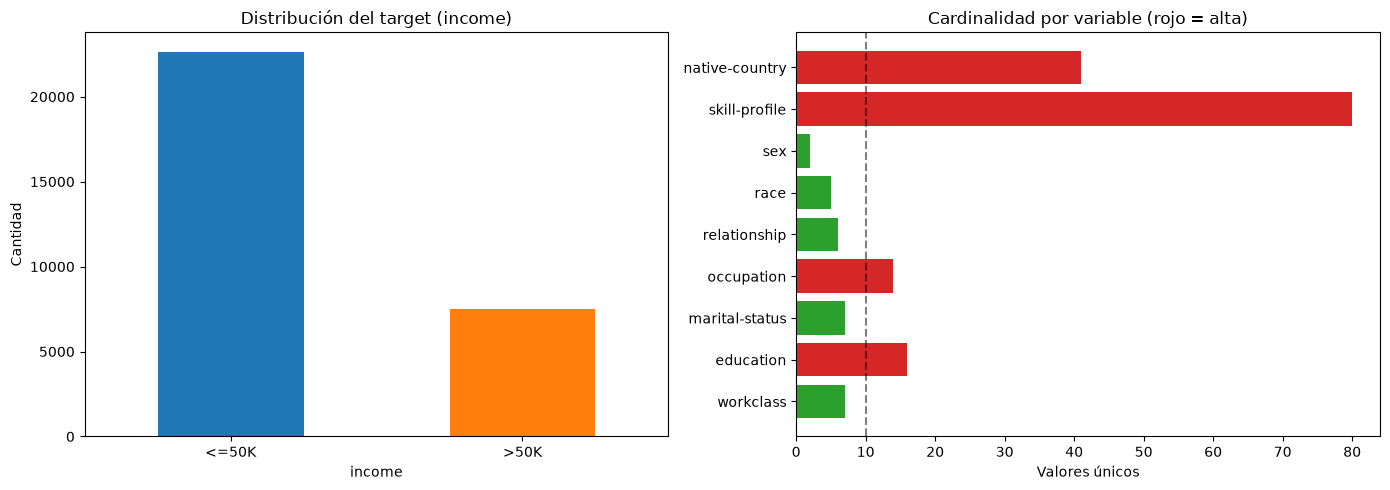

In [3]:
# Gráficos del EDA para análisis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución del target (muestra el desbalance)
train['income'].value_counts().plot(kind='bar', ax=axes[0], color=['tab:blue','tab:orange'])
axes[0].set_title('Distribución del target (income)')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# 2. Cardinalidad de las categóricas
categoricas = ['workclass','education','marital-status','occupation',
               'relationship','race','sex','skill-profile','native-country']
cards = {col: train[col].nunique() for col in categoricas}
colores = ['tab:red' if v >= 10 else 'tab:green' for v in cards.values()]
axes[1].barh(list(cards.keys()), list(cards.values()), color=colores)
axes[1].set_title('Cardinalidad por variable (rojo = alta)')
axes[1].set_xlabel('Valores únicos')
axes[1].axvline(10, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Decisiones de transformación por variable

A partir del análisis de cardinalidad y del contexto de cada variable, adoptamos las siguientes transformaciones:

**Variables numéricas** (`age`, `capital-gain`, `capital-loss`, `hours-per-week`): se aplica **escalado** (estandarización), ya que están en rangos muy distintos (por ejemplo, `age` llega a 90 y `capital-gain` a 99999). Llevarlas a una escala común estabiliza el entrenamiento de la red.

**`sex`** (2 valores): **encoding binario** (0/1). Al tener solo dos categorías, basta con asignar un 0 y un 1; no genera ningún orden falso.

**`workclass`, `marital-status`, `relationship`, `race`** (baja cardinalidad, sin orden): **one-hot encoding**. No poseen un orden natural, y al tener pocas categorías (5-7), one-hot no genera demasiadas columnas nuevas. Sería incorrecto usar ordinal, ya que introduciría una jerarquía inexistente.

**`education`** (alta cardinalidad, con orden): **ordinal encoding**. A diferencia de las demás variables de alta cardinalidad, `education` sí tiene un orden natural (los niveles educativos van de menor a mayor). Por eso conviene preservar esa jerarquía con un encoding ordinal en lugar de un embedding.

**`occupation`, `native-country`, `skill-profile`** (alta cardinalidad, sin orden): **embeddings**. Tienen muchas categorías (14, 41 y 80 respectivamente) y no poseen orden. Con one-hot generarían un número enorme de columnas (por ejemplo, `skill-profile` crearía 80), mientras que un embedding las comprime en pocos valores y además captura similitudes entre categorías.

### Resolución b) Modelo con embeddings

Implementamos un MLP que representa las variables de alta cardinalidad sin orden (`occupation`, `native-country`, `skill-profile`) mediante capas de embedding, aplica ordinal a `education`, one-hot a las categóricas de baja cardinalidad y escalado a las numéricas. La red incluye dropout en las capas ocultas y usa Adam como optimizador con Binary Cross Entropy como función de costo.

In [ ]:
from sklearn.preprocessing import StandardScaler

#Preprocesamiento para el modelo CON embeddings

# Definir los grupos de variables según su transformación
num_cols   = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']       # escalar
emb_cols   = ['occupation', 'native-country', 'skill-profile']                # embedding indice
onehot_cols = ['workclass', 'marital-status', 'relationship', 'race']          # one-hot
# 'education' -> ordinal ; 'sex' -> binario  (los tratamos aparte)

# 1) education: ordinal respetando el orden educativo
orden_educacion = {
    'Preschool':0, '1st-4th':1, '5th-6th':2, '7th-8th':3, '9th':4, '10th':5,
    '11th':6, '12th':7, 'HS-grad':8, 'Some-college':9, 'Assoc-voc':10,
    'Assoc-acdm':11, 'Bachelors':12, 'Masters':13, 'Prof-school':14, 'Doctorate':15
}
train['education'] = train['education'].map(orden_educacion)
val['education']   = val['education'].map(orden_educacion)

#2) sex: binario
train['sex'] = train['sex'].map({'Female':0, 'Male':1})
val['sex']   = val['sex'].map({'Female':0, 'Male':1})

#3) target: income a 0/1
train['income'] = train['income'].map({'<=50K':0, '>50K':1})
val['income']   = val['income'].map({'<=50K':0, '>50K':1})

# 4) embedding cols, convertir a índices enteros
# Cada categoría un número y usamos el train para definir el mapeo.
emb_mapeos = {}      # guardamos el diccionario de cada columna
emb_dims   = {}      # guardamos cuántas categorías tiene cada una
for col in emb_cols:
    categorias = train[col].unique()
    mapeo = {cat: i for i, cat in enumerate(categorias)}
    emb_mapeos[col] = mapeo
    emb_dims[col] = len(categorias)
    train[col] = train[col].map(mapeo)
    # en val, categorías no vistas, las mandamos a un índice extra (len)
    val[col] = val[col].map(mapeo).fillna(len(categorias)).astype(int)
    emb_dims[col] += 1   # +1 por el indice de "desconocido"

#5) ONE-HOT cols
train = pd.get_dummies(train, columns=onehot_cols)
val   = pd.get_dummies(val,   columns=onehot_cols)
# alinear columnas (train y val podrían generar columnas distintas)
train, val = train.align(val, join='left', axis=1, fill_value=0)

#6) Escalar numéricas (fit en train, transform en ambos)
scaler = StandardScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
val[num_cols]   = scaler.transform(val[num_cols])

print("Train procesado:", train.shape)
print("Val procesado:", val.shape)
print("Cardinalidad de embeddings (con +1 desconocido):", emb_dims)

Train procesado: (30162, 35)
Val procesado: (15060, 35)
Cardinalidad de embeddings (con +1 desconocido): {'occupation': 15, 'native-country': 42, 'skill-profile': 81}


### Resolución b) Modelo con embeddings

Construimos un MLP que incorpora **embeddings** para representar las variables de alta cardinalidad (occupation, native-country, skill-profile). La red incluye **dropout** en las capas ocultas para regularizar, usa **Adam** como optimizador y **CrossEntropyLoss** como función de costo, apropiada para clasificación binaria.

In [12]:
import torch
import torch.nn as nn
import numpy as np

# Separar features en embeddings (índices) y el resto
emb_cols = ['occupation', 'native-country', 'skill-profile']

# Columnas que NO son embedding ni el target
resto_cols = [c for c in train.columns if c not in emb_cols + ['income']]

# Tensores para el modelo
# Índices de embedding (enteros -> long)
X_emb_train = torch.tensor(train[emb_cols].values, dtype=torch.long)
X_emb_val   = torch.tensor(val[emb_cols].values,   dtype=torch.long)

# Resto de features (float)
X_resto_train = torch.tensor(train[resto_cols].values.astype(np.float32))
X_resto_val   = torch.tensor(val[resto_cols].values.astype(np.float32))

# Target
y_train = torch.tensor(train['income'].values, dtype=torch.long)
y_val   = torch.tensor(val['income'].values,   dtype=torch.long)

print("Embeddings train:", X_emb_train.shape)   # [30162, 3]
print("Resto train:", X_resto_train.shape)      # [30162, N]
print("Target train:", y_train.shape)
print("N features del resto:", len(resto_cols))

Embeddings train: torch.Size([30162, 3])
Resto train: torch.Size([30162, 31])
Target train: torch.Size([30162])
N features del resto: 31


In [13]:
import torch.nn as nn

# Dimensiones de cada embedding (cardinalidad -> dimensión del vector)
# Regla: más categorías -> más dimensiones, sin pasarse
emb_dims_modelo = {
    'occupation':     (emb_dims['occupation'],     6),   # 15 cats -> vector de 6
    'native-country': (emb_dims['native-country'], 8),   # 42 cats -> vector de 8
    'skill-profile':  (emb_dims['skill-profile'],  12),  # 81 cats -> vector de 12
}

class MLPconEmbeddings(nn.Module):
    def __init__(self, n_resto, emb_dims_modelo):
        super().__init__()
        # Una capa de embedding por cada variable de alta cardinalidad
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cats, dim) for (n_cats, dim) in emb_dims_modelo.values()
        ])
        # Suma de las dimensiones de todos los embeddings
        total_emb = sum(dim for (_, dim) in emb_dims_modelo.values())

        # La entrada al MLP = embeddings concatenados + el resto de features
        entrada = total_emb + n_resto

        self.red = nn.Sequential(
            nn.Linear(entrada, 128),
            nn.ReLU(),
            nn.Dropout(0.3),          # dropout: apaga 30% de neuronas al azar
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)          # salida: 2 clases (<=50K, >50K)
        )

    def forward(self, x_emb, x_resto):
        # Pasar cada índice por su embedding
        emb_out = [emb(x_emb[:, i]) for i, emb in enumerate(self.embeddings)]
        emb_out = torch.cat(emb_out, dim=1)        # concatenar los vectores
        # Unir embeddings + resto
        x = torch.cat([emb_out, x_resto], dim=1)
        return self.red(x)

# Crear el modelo
modelo = MLPconEmbeddings(n_resto=31, emb_dims_modelo=emb_dims_modelo)
print(modelo)

MLPconEmbeddings(
  (embeddings): ModuleList(
    (0): Embedding(15, 6)
    (1): Embedding(42, 8)
    (2): Embedding(81, 12)
  )
  (red): Sequential(
    (0): Linear(in_features=57, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [15]:
import torch.optim as optim
from sklearn.metrics import f1_score, accuracy_score

# ===== Configuración del entrenamiento =====
modelo = MLPconEmbeddings(n_resto=31, emb_dims_modelo=emb_dims_modelo)
criterio = nn.CrossEntropyLoss()                          # función de costo (clasificación)
optimizador = optim.Adam(modelo.parameters(), lr=0.001)   # Adam, lr 0.001
epocas = 50

# Para guardar las métricas por época
hist = {'acc_train':[], 'acc_val':[], 'f1_train':[], 'f1_val':[], 'loss':[]}

for epoca in range(epocas):
    # --- ENTRENAMIENTO ---
    modelo.train()                          # modo train (activa dropout)
    optimizador.zero_grad()                 # limpiar gradientes previos
    salida = modelo(X_emb_train, X_resto_train)   # forward
    loss = criterio(salida, y_train)        # calcular error
    loss.backward()                         # backprop (calcula gradientes)
    optimizador.step()                      # Adam actualiza los pesos

    # --- EVALUACIÓN (sin actualizar, solo medir) ---
    modelo.eval()                           # modo eval (apaga dropout)
    with torch.no_grad():                   # no calcular gradientes (más rápido)
        # predicciones train
        pred_train = modelo(X_emb_train, X_resto_train).argmax(dim=1)
        # predicciones val
        pred_val = modelo(X_emb_val, X_resto_val).argmax(dim=1)

    # métricas
    acc_tr = accuracy_score(y_train, pred_train)
    acc_vl = accuracy_score(y_val, pred_val)
    f1_tr  = f1_score(y_train, pred_train, average='macro')
    f1_vl  = f1_score(y_val, pred_val, average='macro')

    hist['acc_train'].append(acc_tr); hist['acc_val'].append(acc_vl)
    hist['f1_train'].append(f1_tr);   hist['f1_val'].append(f1_vl)
    hist['loss'].append(loss.item())

    if epoca % 5 == 0 or epoca == epocas-1:
        print(f"Época {epoca:2d} | loss {loss.item():.4f} | acc_val {acc_vl:.4f} | f1_val {f1_vl:.4f}")

print("\nEntrenamiento terminado...")

Época  0 | loss 0.7265 | acc_val 0.6085 | f1_val 0.5086
Época  5 | loss 0.5928 | acc_val 0.7543 | f1_val 0.4300
Época 10 | loss 0.5740 | acc_val 0.7543 | f1_val 0.4300
Época 15 | loss 0.5372 | acc_val 0.7546 | f1_val 0.4311
Época 20 | loss 0.4973 | acc_val 0.7665 | f1_val 0.4835
Época 25 | loss 0.4588 | acc_val 0.8063 | f1_val 0.6442
Época 30 | loss 0.4224 | acc_val 0.8230 | f1_val 0.7063
Época 35 | loss 0.3932 | acc_val 0.8357 | f1_val 0.7551
Época 40 | loss 0.3725 | acc_val 0.8414 | f1_val 0.7787
Época 45 | loss 0.3565 | acc_val 0.8471 | f1_val 0.7847
Época 49 | loss 0.3476 | acc_val 0.8511 | f1_val 0.7957

Entrenamiento terminado...


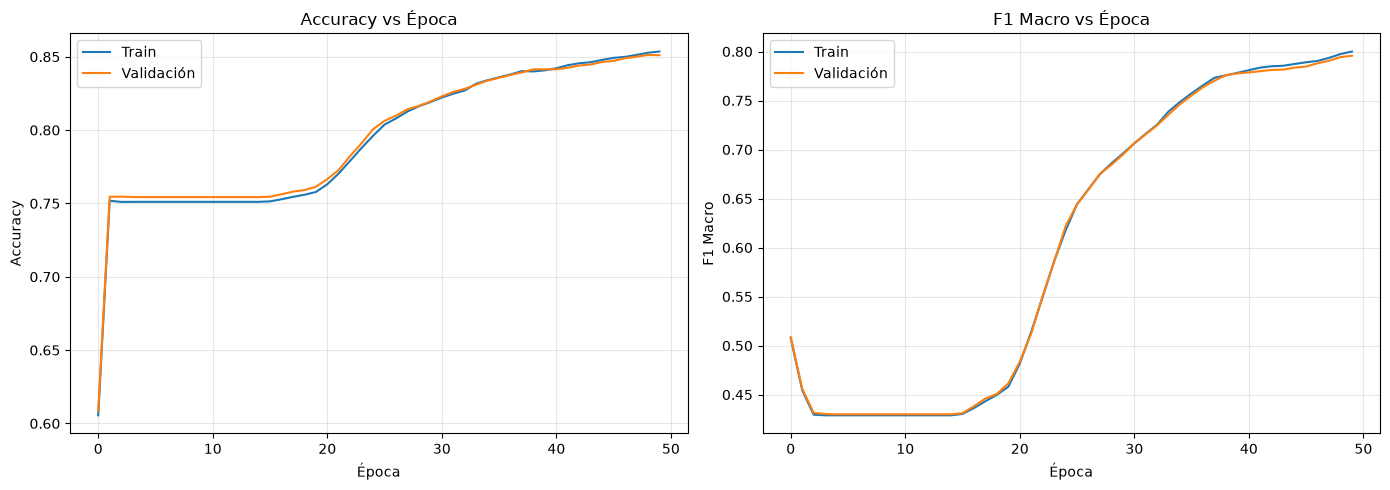

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs época
axes[0].plot(hist['acc_train'], label='Train', color='tab:blue')
axes[0].plot(hist['acc_val'], label='Validación', color='tab:orange')
axes[0].set_title('Accuracy vs Época')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# F1 macro vs época
axes[1].plot(hist['f1_train'], label='Train', color='tab:blue')
axes[1].plot(hist['f1_val'], label='Validación', color='tab:orange')
axes[1].set_title('F1 Macro vs Época')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('F1 Macro')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

CLASSIFICATION REPORT (validación):
              precision    recall  f1-score   support

       <=50K       0.90      0.91      0.90     11360
        >50K       0.71      0.67      0.69      3700

    accuracy                           0.85     15060
   macro avg       0.80      0.79      0.80     15060
weighted avg       0.85      0.85      0.85     15060



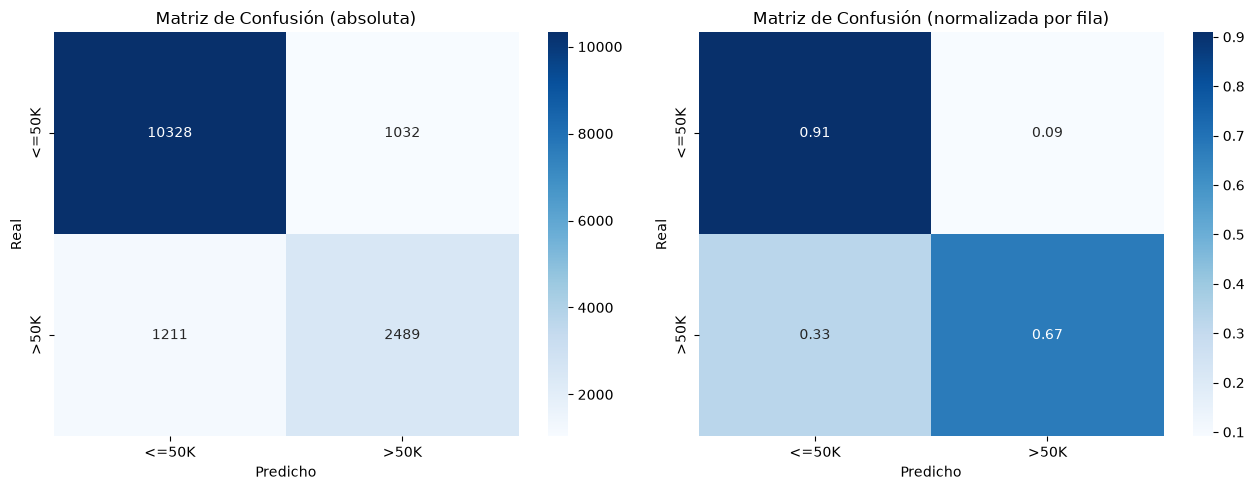

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predicciones finales en validación
modelo.eval()
with torch.no_grad():
    pred_val = modelo(X_emb_val, X_resto_val).argmax(dim=1)

# --- Classification report ---
print("CLASSIFICATION REPORT (validación):")
print(classification_report(y_val, pred_val, target_names=['<=50K', '>50K']))

# --- Matriz de confusión ---
cm = confusion_matrix(y_val, pred_val)                          # absoluta
cm_norm = confusion_matrix(y_val, pred_val, normalize='true')  # normalizada por fila

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
axes[0].set_title('Matriz de Confusión (absoluta)')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=['<=50K','>50K'], yticklabels=['<=50K','>50K'])
axes[1].set_title('Matriz de Confusión (normalizada por fila)')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()